继续我们的实践经验，我们现在将重点放在我们最重要的一章，关于只使用Python的代码，这从本质上简化了GPU计算方法。我们将重温Anaconda和一个简短的重新介绍后，包括Miniconda，我们将开始我们的探索，探讨它与GPU计算的角度。特别是，将介绍CuPy和Numba，以突出仅Python语法对于GPU计算的重要性。我们将通过丘比和努巴以一种更简单的方式无缝地重构我们先前的例子来实现同样的目标。

Python编程爱好者将被鼓励在他们的程序代码中使用CuPy和CUDA-enabled-Numba调用NVIDIA-GPU，同时也不排除AMD-GPU用户使用ROCm-enabled-Numba进行实验。我们首先通过回顾第一个传统的Python程序，然后将同一个程序结构与CuPy的程序结构进行比较，来了解CuPy程序是如何工作的。接下来，我们将继续这一章，通过CUDA和启用ROCm的Numba进行计算蟒蛇。我们关注CuPy和Numba对传统NumPy的适用性偏好，这与Python语法极其相似，但功能更强大。

本章将讨论以下主题：
- 了解Anaconda如何与CuPy和Numba一起工作
- 安装CuPy和Numba以及如何使其在现有的PyCharm环境中与Anaconda识别
- 在PyCharm上实现CuPy和Numba的定制实践示例
- 在PyCharm上写你的第一个CuPy和Numba程序
- 基于GPU的CuPy和Numba计算问题求解
- 理解仅用Python语法解决计算问题的意义

# 了解Anaconda如何与CuPy和Numba一起工作

到目前为止，您一定已经熟悉了免费的开源Anaconda发行版，因为到目前为止，我们已经在所有代码示例中使用了它。让我们进一步探索Anaconda，了解它的更多特性，特别是在加速计算方面。Anaconda中的加速计算在Python科学计算部署中具有极其重要的意义。

到目前为止，我们涵盖了包括C/C++语法在内的Python编程实现。但从现在开始，我们必须更多地关注纯Python语法的编程实现，这对于保持Python的无缝编程体验非常重要，无论CPU或GPU平台如何。采用这种方法使Python程序员更容易迁移到支持GPU的体验。GPU语法与Python上的CPU语法越相似，Python加速计算的通用性就越好。

在第6章，使用CUDA和PyCUDA，以及第7章，使用ROCm和PyOpenCL中，我们学习了以不同的方式实现并行操作，即通过CUDA、HIP、OpenCL、PyCUDA和PyOpenCL。在本章中，我们还将继续实现这一点，因为学习用不同的方法解决问题有助于理解问题及其解决方案。

但在我们这么做之前，让我们先简单地重温一下水蟒，并了解它与Miniconda的区别。我们已经知道Anaconda是一个包管理和部署分发。然而，它也包括许多内置的科学软件包。但是，如果您的需求对于某个特定的应用程序非常具体，那么您可以选择Miniconda，它只包含存储库管理系统，而不包含任何额外的包。让我们更深入地了解它们的区别，如下表所示：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td>
<p><strong>Anaconda</strong></p>
</td>
<td>
<p><strong>Miniconda</strong></p>
</td>
</tr>
<tr>
<td>
<p>Preferable for beginners.</p>
</td>
<td>
<p>Preferable for experienced users.</p>
</td>
</tr>
<tr>
<td>
<p>Consists of the repository management system that includes over 150 scientific packages.</p>
</td>
<td>
<p>Consists of only the repository management system without any extra packages.</p>
</td>
</tr>
<tr>
<td>
<p>Focused on a multi-purpose experience.</p>
</td>
<td>
<p>Focused on a more customized experience.</p>
</td>
</tr>
<tr>
<td>
<p>Requires access to a minimum of 3 GB disk space.</p>
</td>
<td>
<p>Requires only 400 MB of disk space.</p>
</td>
</tr>
<tr>
<td>
<p>An Anaconda installer is around 650 MB.</p>
</td>
<td>
<p>A Miniconda installer is only around 65 MB.</p>
</td>
</tr>
<tr>
<td>
<p>Individual package installation not required.</p>
</td>
<td>
<p>Requires installation of specific individual packages.</p>
</td>
</tr>
</tbody>
</table>

Anaconda和Miniconda都提供了Conda的用法，我们现在将简要地了解它。

Anaconda团队构建、审查和维护数千个软件包https://repo.continuum.io/pkgs/ 。要安装和管理所有这些软件包，可以在Conda的默认Anaconda或Miniconda配置中使用Conda。

2019年4月4日，AnacondaCON宣布推出新版本的PyCharm，增强了对Anaconda的支持。它被称为AnacondaCON，可以从

https://www.jetbrains.com/pycharm/promo/anaconda/。

## Conda

与Anaconda一样，Conda是一个开放源代码包和环境管理系统，可以快速安装、运行和更新包及其依赖项，同时还可以方便地在计算机上创建、保存、加载以及在本地虚拟环境之间切换。在前面的章节中，我们已经通过实践经验学到了这些。Conda最初是为Python程序创建的，但它可以打包和分发任何语言的软件，包括R, Ruby, Lua, Scala, Java, JavaScript, C/ C++,和FORTRAN。

## CuPy

CuPy是一个与NumPy高度兼容的开源接口，NumPy是用Python进行科学计算的基本包。由于它遵循相同的NumPy模型，仅适用于CUDA GPU，因此在大多数情况下，它可以作为NumPy的替代品。只需在Python代码中将numpy替换为cupy即可。我们将在本章后面探讨一个比较示例。

CuPy还使用NVIDIA的CUDA相关库，如cuBLAS、cuDNN、cuSolver、cuSPARSE、cuFFT、cuRand和NCCL，来利用CUDA GPU架构。

就像NumPy的一样`numpy.ndarray`，CuPy通过`cupy.ndarray`. 我们将在下一节学习设置。

## Numba

Numba也是一个针对Python的开源即时（JIT）编译器，可以有效地处理使用NumPy数组、函数和循环的代码。它将Python和NumPy代码的子集转换为快速机器代码。它使用了一组装饰器，可以应用于Python函数进行编译。当调用一个Numba修饰函数时，它会被编译成机器代码JIT来执行，并且您的代码随后可以以本机机器代码速度（CPU或GPU）运行。

JIT编译器在程序启动后运行，并编译字节码（从源代码编译成低级代码）。通过这种方式，JIT可以访问动态运行时信息，从而能够更好地调优代码。在传统的编译器中，这是不可能的，因为它在执行程序之前将整个代码编译成机器语言。

### 基于Python的GPU加速Numba

Numba可以在NVIDIA CUDA和AMD ROCm GPU上实现，尽管后者仍在试验中：

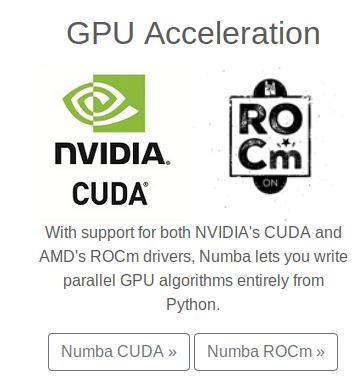

在我们进入下一节的安装过程之前，让我们先简要了解一下它们：
- Numba-CUDA:NVIDIA-CUDA-GPU使用Numba计算可以通过直接将Python代码的受限子集编译成CUDA内核和设备函数来实现。计算统一设备体系结构（CUDA）执行模型是NUBBA CUDA的基础。
- Numba-ROCm:AMD-ROC-GPU使用Numba计算可以通过直接将Python代码的受限子集编译成HSA内核和设备函数来实现。异构系统体系结构（HSA）的执行模型是NUBA BA ROM的基础。

Numba内核似乎可以直接访问NumPy数组，这些数组可以在CPU和GPU之间自动传输。

# 在现有Anaconda环境中安装CuPy和Numba for Python

在这里，我们将学习如何将CuPy和Numba集成到我们的代码开发环境中，以便我们能够以比PyCUDA和PyOpenCL更简单的方式与GPU设备通信。

## 将Python与CuPy耦合

既然我们已经了解了CUDA的安装和实现，那么现在我们可以更容易地开始Python的CuPy安装过程，因为它最初是为实现CUDA而开发的。我们还了解了Anaconda及其设置，因此可以使用python2.x或3.x，这在现有Anaconda配置中很容易获得。设置CuPy可以在现有的Python设置中实现CUDA内核，然后在nvidiagpu上使用它进行计算。

系统范围内安装的NVIDIA驱动程序版本应始终大于或至少等于toolkit（Conda package）版本。如果一个系统有cuda9.0（驱动程序和工具包都安装在系统范围内），但是是根据CUDA的早期版本编译的，比如7.5（Conda包），cuda9.0会自动让cuda7.5conda包安装与旧的工具包一起工作。但是如果是相反的方式，那么就无法编译，因为9.0（Conda包）工具包与7.5系统范围的驱动程序不兼容。

要在安装过程中使用conda并在详细模式下获取逐行报告，请在使用conda安装包时使用--debug标志。例如，考虑以下因素：

conda安装<package name>--调试。这样，您就不必等待收集包元数据和解决环境消息，并且可以记录整个安装过程。

## 基于Conda的CuPy安装

这是在生产环境中开始使用CuPy的推荐方法。通过使用虚拟环境，您可以安全地试验编程技能，而不会影响系统范围的Python设置。
要在水蟒体内设置CuPy，请遵循以下说明：

首先，让我们用以下命令在终端上安装cupy和conda。输入y继续。根据Anaconda安装的更新状态，第一个命令是必需的。在这里，我们还特别为CUDA 9.0选择了cudatoolkit conda软件包（安装在系统范围内）：

## 基于pip的CuPy安装

在完成了基于Conda的CuPy安装之后，让我们探索另一种也可以使用的方法。可以使用pip在本地环境中安装CuPy。以下代码演示了如何执行此操作：

注意，pip install--user cupy-cuda90执行与pip3 install--user cupy-cuda90相同的操作。cuda10.0的命令是pip3 install cupy-cuda100。

安装CuPy for Python 2.x的替代命令如下：

注意，前面的命令是针对cuda9.0的。CuPy还支持8.0、9.1、9.2和10.0版本。

只使用cupy而不是cupy-9-0将从源代码安装它。现在，您已经有了一个用户指定的配置，可以在您的Ubuntu Linux系统上使用CuPy系统范围。

## 将Python与Numba耦合用于CUDA和ROCm

既然我们已经了解了CUDA的安装和实现，那么现在我们就可以更轻松地开始Python的Numba安装过程了。您不需要安装Python，因为新安装的ubuntu18.04linux操作系统已经提供了Python（2.x和3.x）。

### 为NVIDIA CUDA gpu安装带有Conda的Numba

对于生产环境，这是开始使用加速Numba的推荐方法。

要在Anaconda内为CUDA设置NUBA，请遵循以下说明：

首先，让我们用以下conda命令在终端上安装numba。输入y继续。根据Anaconda安装的更新状态，第一个命令是必需的。此外，我们在这里选择专门用于CUDA 9.0的cudatoolkit Conda软件包（安装在系统范围内）：

### 使用Conda为AMD ROC gpu安装Numba

### 带pip的Nuba全系统安装（可选）

请注意，pip还可以用于在系统范围内安装Numba，甚至可以使用以下命令在本地Conda安装（前提是pip在本地安装，Conda install pip）：

在下一节中，我们将学习如何在PyCharm IDE上配置基于Conda和用户指定的系统范围配置。

## 在Python IDE上配置CuPy

以下步骤特定于PyCharm IDE。但是如果您喜欢不同的IDE，仍然可以使用这些步骤作为设置CuPy的参考，因为过程非常相似。为了使用PyCharm配置CuPy，我们将重点放在基于Conda的安装上：

1. 首先，让我们用Conda作为一个新的PyCharm纯Python项目来创建一个虚拟环境。选择新项目。。。从PyCharm主菜单：

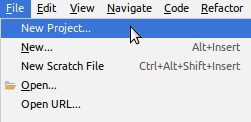

2. 在新的本地Conda环境中创建纯Python项目，如以下屏幕截图所示：

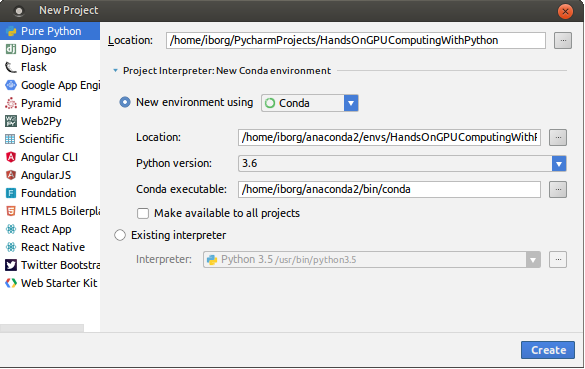

3. 等待创建环境，如图所示：

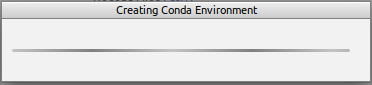

4. 创建Conda环境后，您将拥有一个随时可用的CuPy开发环境，如以下屏幕截图所示：

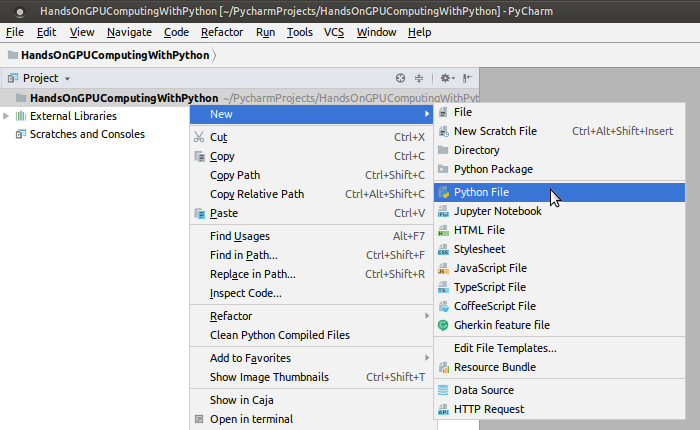

现在可以在Python程序中导入cupy了。如您所见，当您开始键入import cupy时，PyCharm Edu会检测并建议您：

从cupy导入cuda模块的确认，如以下屏幕截图所示：

在这个阶段，我们已经完成了在PyCharm IDE上配置CuPy。

# CuPy中的计算如何在Python上工作

通过与Python上NumPy代码的传统用法进行并行比较，可以非常容易地理解使用CuPy进行GPU计算的基础知识。

一旦我们探索了简单的术语，我们将把注意力转移到实际的GPU加速计算上，用CuPy解决特定的计算问题。

如果您还记得我们在PyCUDA一章中首先描述的传统NumPy程序，我们实现了一个函数，通过NumPy将两个数组元素相乘。我们用于导入numpy的语法如下：

In [1]:
import numpy as np

如您所见，numpy缩写为np是为了方便在整个程序代码中使用。

对于CuPy，我们也可以使用类似的语法，如下所示：

In [3]:
import cupy as cp

在NumPy代码中，我们使用以下语法为N个值为零值的元素初始化了两个double数据类型的数组：

In [5]:
N = 100000
p = np.zeros(N, dtype=np.double)

在丘比，使用这种语法没有区别。但是它不是在主机（CPU）上创建的，而是在设备（GPU）上创建的，如下所示：

In [6]:
p = cp.zeros(N, dtype=cp.double)

为了根据我们的选择更改每个数组的所有值，我们使用`numpy.ndarray.fill`填充，如下所示：

In [7]:
p.fill(23.0)

如果我们用cupy替换numpy import，我们不必更改前面声明中的任何内容。完全一样。

我们还使用NumPy来设置0到N之间的随机整数索引值，如下所示：

In [8]:
random = np.random.randint(0, N)

对CuPy来说，也没什么不同。只需将np替换为cp即可使用GPU进行随机操作，如下所示：

In [9]:
random = cp.random.randint(0, N)

CuPy还可以用于将使用NumPy创建的数组移动到GPU设备，如下所示：

In [10]:
p = np.zeros(N, dtype=np.double)
p_gpu = cp.asarray(p)

使用它执行我们选择的数学运算后，我们可以通过以下方式将GPU设备阵列移回主机：

In [11]:
p = cp.asnumpy(p_gpu)

您还可以使用以下选项：

In [12]:
p = p_gpu.get()

您可能还记得，ElementwiseKernel是在第6章中首先探讨的，使用CUDA和PyCUDA，使用PyCUDA，如下所示：

In [14]:
import pycuda.autoinit
import pycuda.driver as cudadrv
import numpy
import pycuda.gpuarray as gpuarray
from pycuda.elementwise import ElementwiseKernel

multiply = ElementwiseKernel(
      "double *a_gpu, double *b_gpu",
      "b_gpu[i] = a_gpu[i] * b_gpu[i]",
      "multiply")

以类似的方式，您也可以使用CuPy来实现相同的功能，只需做如下非常小的修改：

In [ ]:
multiply = cp.ElementwiseKernel(
      "double *a_gpu, double *b_gpu",
      "b_gpu[i] = a_gpu[i] * b_gpu[i]",
      "multiply")

# 用CuPy实现多gpu

当在同一系统上使用多个GPU时，CuPy可以用来指定要使用的确切GPU设备。默认情况下，设备（0）是第一个GPU。

要指定第二个GPU，我们可以使用以下命令，其中第二个GPU设备（1）用于初始化p数组：

In [16]:
cp.cuda.Device(1).use()
p = np.zeros(N, dtype=np.double)

默认情况下，所有操作都在第一个GPU设备（0）上完成。与设备（0）一起使用时，在设备（1）上创建的数组将不起作用。

也可以将阵列从GPU 1移动到GPU 2，就像从CPU移动到GPU一样，如下所示：

In [17]:
with cp.cuda.Device(0):
gpu1 = np.zeros(N, dtype=np.double)
with cp.cuda.Device(1):
gpu2 = cp.asarray(gpu1) # Moving array to the second GPU

IndentationError: expected an indented block (<ipython-input-17-7fd2db6cb36d>, line 2)

要确认正在使用的GPU设备，可以使用以下命令：

In [18]:
print(p.device) # where p is our array used earlier

AttributeError: 'numpy.ndarray' object has no attribute 'device'

以下输出将显示在单个GPU设置上：

在下一节中，我们将学习如何在PyCharm上使用CUDA和ROCm配置Numba。

# 在Python IDE上配置Numba

您可以使用以下步骤作为设置Numba的参考，因为过程非常相似。为了使用PyCharm配置Numba，我们再次关注基于Conda的安装：

1. 首先，让我们用Conda作为一个新的PyCharm纯Python项目来创建一个虚拟环境。选择新项目。。。从PyCharm主菜单，如以下屏幕截图所示：

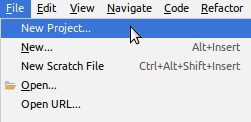

2. 在新的本地Conda环境中创建纯Python项目。如果已经创建了一个，请跳过此步骤：

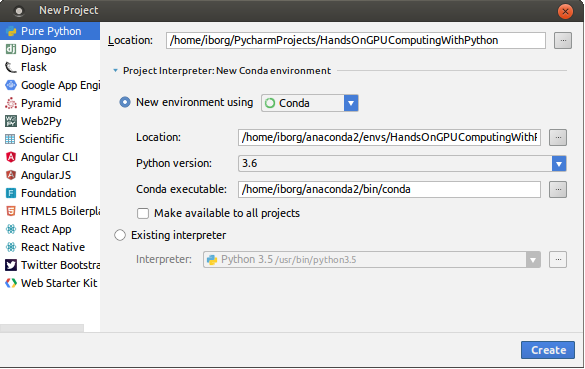

3. 等待创建环境，如下所示：

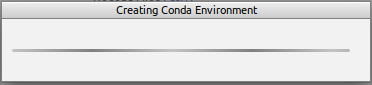

4. 创建Conda环境后，您将拥有一个随时可用的Numba开发环境，如以下屏幕截图所示：

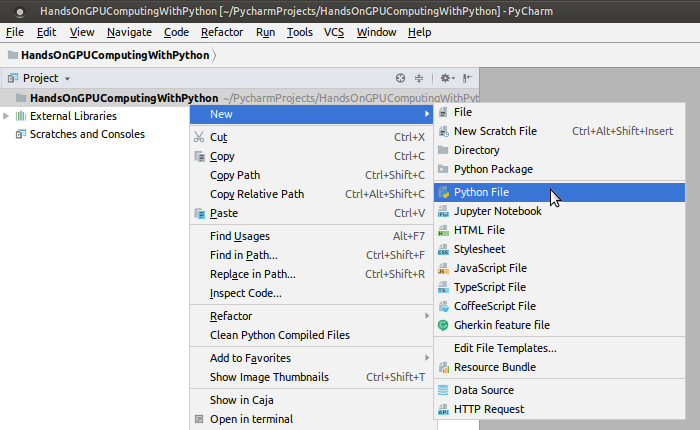

现在可以在Python程序中导入import numba。

正如您在下面看到的，当您开始键入import numba时，PyCharm Edu会检测并建议您这样做：

In [1]:
import numba

以下屏幕截图显示了从numba导入cuda的确认：

从numba导入roc的确认如此截图所示：

在这个阶段，我们已经完成了在PyCharm IDE上配置Numba。现在让我们在下一节中探讨Numba中的计算是如何在Python上工作的。

# Numba中的计算如何在Python上工作

要理解使用Numba进行GPU计算的基础知识，首先了解@jit装饰器的工作原理是很重要的。这是麻木的中心特征。使用这个decorator，Numba的JIT编译器可以用来优化函数。

要从Numba导入jit，我们使用以下语法：

In [2]:
from numba import jit

在传统的Python中，我们使用以下语法来定义函数（回想一下我们以前使用的基于乘法函数的传统程序）：

In [3]:
def multiply(p_cpu, q_cpu):
    for i in range(N):
        q_cpu[i] = p_cpu[i] * q_cpu[i]

要在Numba中使用JIT，我们只需在定义函数之前添加以下内容：

In [4]:
@jit
def multiply(p_cpu, q_cpu):
    for i in range(N):
        q_cpu[i] = p_cpu[i] * q_cpu[i]

前面的更改将允许JIT编译器接管multiply函数，并在执行时将其转换为快速机器代码。

要使Numba在代码未优化时报告错误，可以改用@njit，这是对@jit的简短替换（nopython=True）。

使用Numba，我们还可以使用其他装饰器，比如@vectorize、@guvectorize、@stencil、@jitclass、@cfunc和@overload。

对于我们的GPU计算目标，让我们关注@vectorize decorator来实现CUDA和ROCm。

在前面讨论丘比的时候，我们简单地讨论了努比。Numba的vectorize允许Python函数采用标量输入参数作为NumPy ufuncs。创建一个传统的numpyufunc需要编写C代码。Numba通过使用vectorize（）修饰符使ufuncs变得简单。使用vectorize，Numba可以将一个纯Python函数编译成一个ufunc，这个ufunc可以在NumPy数组上运行，运行速度与用C编写的传统ufunc相当。

## 使用矢量化

要使用矢量化修饰符，我们可以使用与JIT修饰符相同的语法。以下代码显示了使用vectorize作为动态通用函数（DUFunc）实现的多个函数：

In [5]:
@vectorize
def multiply(p, q):
    q = p * q

NameError: name 'vectorize' is not defined

我们称之为动态通用函数，因为没有传递到@vectorize decorator的签名。

传递签名时，代码将修改如下：

In [6]:
@vectorize(["float32(float32, float32)"])
def multiply(p, q):
    q = p * q

NameError: name 'vectorize' is not defined

现在，让我们看看NVIDIA CUDA GPU的GPU实现是如何实现的：

In [7]:
@vectorize(["float32(float32, float32)"], target='cuda')
def multiply(p, q):
    q = p * q

NameError: name 'vectorize' is not defined

对于ROCm（实验性），以下语法将使用AMD ROCm GPU进行HSA：

In [8]:
@vectorize(["float32(float32, float32)"], target='roc')
def multiply(p, q):
    q = p * q

NameError: name 'vectorize' is not defined

## 显式核

您还可以使用Numba在nvidiacuda或amdrocm（HSA）中显式地编写内核。

在CUDA中，我们使用我们已经熟悉的语法：

In [9]:
@cuda.jit
def multiply(p, q):
    # Thread id in a 1D block
    tx = cuda.threadIdx.x
    # Block id in a 1D grid
    ty = cuda.blockIdx.x
    # Block width, i.e. number of threads per block
    bw = cuda.blockDim.x
    # Computing flattened index inside the array
    index = tx + ty * bw
    if index < N: # Check array size limit
        q[index]=p[index]*q[index]

NameError: name 'cuda' is not defined

在ROCm中，我们使用以下OpenCL语法：

In [10]:
@roc.jit
def multiply(p, q):
    # workitem id in a 1D workgroup
    tx = roc.get_local_id(0)
    # workgroup id in a 1D grid
    ty = roc.get_group_id(0)
    # workgroup size, i.e. number of workitems per workgroup
    bw = roc.get_local_size(0)
    # Computing flattened index inside the array
    index = tx + ty * bw
    # The above is equivalent to pos = roc.get_global_id(0)
    if index < N: # Check array size limit
        q[index]=p[index]*q[index]

NameError: name 'roc' is not defined

在下一节中，我们将学习在PyCharm上编写我们的第一个CuPy和Numba程序。

# 编写第一个CuPy和Numba加速程序来计算GPGPU解决方案

首先从CuPy开始，我们将在我们的第一个CuPy程序中应用到目前为止我们了解到的关于CuPy的实现。注意，它也不使用NumPy来生成随机数。事实上，这是一个纯粹的丘比计划。NumPy模块根本没有导入。

1. 首先，在PyCharm上打开一个新文件，如屏幕截图所示：

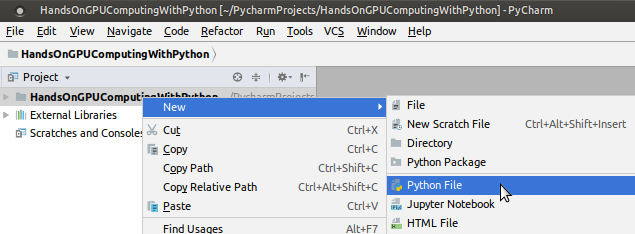

2. 现在使用下面的代码将NumPy语法简单地替换为CuPy。这是CuPy中的一种常规基本格式，除了导入后一个模块外，与NumPy完全相同：

In [11]:
import cupy as cp #Importing CuPy
from timeit import default_timer as timer #To record computation time

N = 5000000 #500 million elements

# Starting timer to record GPU computation time
start = timer()
# Setting two arrays all with zero values
a_cp = cp.zeros(N).astype(cp.double)
b_cp = cp.zeros(N).astype(cp.double)

# Initializing two values for each array
a_cp.fill(23.0)
b_cp.fill(12.0)
#Updating second array as a product of both arrays
b_cp = a_cp * b_cp

请注意，我们还使用CuPy而不是NumPy来生成随机数，如下所示：

In [12]:
# Choosing a random index
random = cp.random.randint(0,N)
# Displaying random element
print("Choosing array element %d at random:" % random)
print("Random array element value is %lf" % b_cp[random])
# Displaying current GPU device
print(b_cp.device)
# GPU computation time
cupy_gpu_time = timer() - start
#Displaying GPU computation time
print("CuPy on GPU took %f seconds." % cupy_gpu_time)

Choosing array element 2162953 at random:
Random array element value is 276.000000
<CUDA Device 0>
CuPy on GPU took 30.360445 seconds.


输出如下：

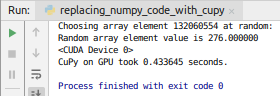

我们还可以使用CuPy来编写原始CUDA内核。原始CUDA内核需要适当的结构才能获得必要的输出。因此，请确保在执行之前正确缩进代码，如下所示：

In [13]:
import cupy as cp #Importing CuPy
# Defining the CUDA kernel
multiply = cp.RawKernel(r'''
extern "C" __global__
void multiply(const int* p, const int* q, int* z) {
 int tid = blockDim.x * blockIdx.x + threadIdx.x;
 z[tid] = p[tid] * q[tid];
}
''', 'multiply')

与NumPy一样，我们也可以使用CuPy来管理数组，如下代码所示：

In [14]:
# First two arrays are set as 0,1,2,3....upto 300
p = cp.arange(300, dtype=cp.int)
q = cp.arange(300, dtype=cp.int)

# Setting a new array with zeros to pass to kernel for computation
z = cp.zeros(300, dtype=cp.int)

# Invoking the kernel with a grid of 250 blocks, each consisting of 1024 threads
multiply((250,1), (1024,1), (p, q, z)) # grid, block and arguments

# Displaying the output computed on the kernel
print(z)

[    0     1     4     9    16    25    36    49    64    81   100   121
   144   169   196   225   256   289   324   361   400   441   484   529
   576   625   676   729   784   841   900   961  1024  1089  1156  1225
  1296  1369  1444  1521  1600  1681  1764  1849  1936  2025  2116  2209
  2304  2401  2500  2601  2704  2809  2916  3025  3136  3249  3364  3481
  3600  3721  3844  3969  4096  4225  4356  4489  4624  4761  4900  5041
  5184  5329  5476  5625  5776  5929  6084  6241  6400  6561  6724  6889
  7056  7225  7396  7569  7744  7921  8100  8281  8464  8649  8836  9025
  9216  9409  9604  9801 10000 10201 10404 10609 10816 11025 11236 11449
 11664 11881 12100 12321 12544 12769 12996 13225 13456 13689 13924 14161
 14400 14641 14884 15129 15376 15625 15876 16129 16384 16641 16900 17161
 17424 17689 17956 18225 18496 18769 19044 19321 19600 19881 20164 20449
 20736 21025 21316 21609 21904 22201 22500 22801 23104 23409 23716 24025
 24336 24649 24964 25281 25600 25921 26244 26569 26

输出如下：

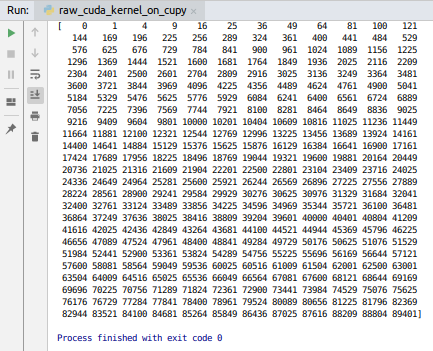

在前面的程序中，我们将原始CUDA内核中的两个数组元素相乘。

现在让我们关注我们的第一个Numba程序。使用JIT，我们将常规的numpy Python程序（第6章PyCUDA中的计算如何在Python上工作的第一个示例，使用CUDA和PyCUDA）修改如下：

In [15]:
import numpy as np # Importing NumPy
from numba import njit # Importing njit module from Numba
from timeit import default_timer as timer # To record computation time

N = 5000000 # 500 Million Elements
# Function to multiply two array elements and also update the results on the second array
@njit #Equivalent to @jit(nopython=True)
def multiply(p_cpu, q_cpu):
    for i in range(N):
        q_cpu[i] = p_cpu[i] * q_cpu[i]

def main():
    #Initialize the two arrays of double data type all with 0.0 values upto N
    p = np.zeros(N, dtype=np.double)
    q = np.zeros(N, dtype=np.double)
    # Update all the elements in the two arrays with 23.0 and 12.0 respectively
    p.fill(23.0)
    q.fill(12.0)
    # Time the Function
    begin = timer()
    multiply(p, q)
    numpy_cpu_time = timer() - begin
    # Report Computation Time
    print("Function took %f seconds." % numpy_cpu_time)
    # Choose a random integer index value between 0 to N
    random = np.random.randint(0, N)
    # Verify all values to be 276.0 for second array by random selection
    print("New value of second array element with random index", random, "is", q[random])
    return 0

我们现在在这里使用NumPy。看到如何在同一个程序中同时使用CuPy（替换NumPy）和Numba来实现互操作性。

最后，我们将主Python函数设置为启动完整的代码，如下所示：

In [16]:
if __name__ == "__main__":
    main()

Function took 1.249417 seconds.
New value of second array element with random index 3670644 is 276.0


输出如下：

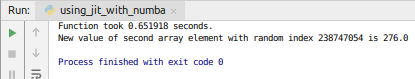

在下一个程序中，我们尝试使用基于Numba的矢量化装饰器，并指定一个CUDA目标：

In [1]:
import numpy as np # Importing NumPy
from timeit import default_timer as timer # To record computation time
from numba import vectorize #Importing vectorize module from Numba

N = 5000000 #500 million elements

#The @vectorize decorator turns the function into a GPU-based vectorized function.
@vectorize(["double(double, double)"], target='cuda')
def vector_multiply_gpu(a, b):
    return a * b

def main():
    #Initialize the two arrays of double data type all with 0.0 values upto N
    p = np.zeros(N, dtype=np.double)
    q = np.zeros(N, dtype=np.double)
    # Update all the elements in the two arrays with 23.0 and 12.0 respectively
    p.fill(23.0)
    q.fill(12.0)
    
    '''
    设置计时器来计算矢量化函数的计算时间
    '''
    # Time the GPU function
    start = timer()
    # Display computed array
    print(vector_multiply_gpu(p, q))
    vector_multiply_gpu_time = timer() - start
    # Report Computation Time
    print("GPU function took %f seconds." % vector_multiply_gpu_time)
    return 0

if __name__ == "__main__":
    main()

[276. 276. 276. ... 276. 276. 276.]
GPU function took 1.596983 seconds.


我们讨论了用Numba编写CUDA和ROCm内核的方法。以下程序是针对CUDA的。请注意，定义内核是非常简单和容易的，没有任何C/C++代码，尽管它非常相似和熟悉：

In [1]:
from numba import cuda # Importing cuda module from Numba
import numpy as np # Importing NumPy
from timeit import default_timer as timer #To record computation time

N = 5000000 # 500 million elements

@cuda.jit
def multiply(p, q):
    # Thread id in a 1D block
    tx = cuda.threadIdx.x
    # Block id in a 1D grid
    ty = cuda.blockIdx.x
    # Number of threads per block
    bw = cuda.blockDim.x
    # Computing flattened index inside the array
    index = tx + ty * bw
    if index < N: # Check array size limit
        q[index]=p[index]*q[index]

请注意，前一行类似于CUDA语法`—index = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x`:

In [2]:
#Initialize the two arrays of double data type all with 0.0 values upto N
a_source = np.zeros(N, dtype=np.double)
b_source = np.zeros(N, dtype=np.double)
a_source.fill(23)
b_source.fill(12)
threadsperblock = 1024
blockspergrid = (N + (threadsperblock - 1)) // threadsperblock
# Time the GPU function
start = timer()
multiply[blockspergrid, threadsperblock](a_source,b_source)
vector_multiply_gpu_time = timer() - start
'''
报告计算时间并为值生成随机索引的代码
'''
# Report GPU Computation time
print("GPU function took %f seconds." % vector_multiply_gpu_time)
random = np.random.randint(0,N)

print("Choosing array element %d at random:" % random)
print("Random array element value is %lf" % b_source[random])

GPU function took 0.987846 seconds.
Choosing array element 4033224 at random:
Random array element value is 276.000000


如果我们用CuPy替换NumPy导入，前面的Numba程序将如何工作？让我们在下一节找到答案。

# 在单个Python程序中CuPy和Numba之间的互操作性

在本节中，我们尝试测试同一Python程序中两个不同模块之间的互操作性，即CuPy和Numba。因此，我们也从numba和cupy导入了cuda模块：

In [1]:
from numba import cuda #Using Numba
import cupy as cp #Using CuPy
from timeit import default_timer as timer

N = 5000000

@cuda.jit
def multiply(p, q):
    # Thread id in a 1D block
    tx = cuda.threadIdx.x
    # Block id in a 1D grid
    ty = cuda.blockIdx.x
    # Number of threads per block
    bw = cuda.blockDim.x
    # Compute flattened index inside the array
    index = tx + ty * bw
    
    '''
    与上一个程序一样，我们根据一个条件计算乘积
    '''
    if index < N: # Check array size limit
        q[index]=p[index]*q[index]

In [2]:
a_source = cp.zeros(N, dtype=cp.double)
b_source = cp.zeros(N, dtype=cp.double)
a_source.fill(23)
b_source.fill(12)
'''
在这里，我们为NVIDIA Titan X GPU设置每个块的最大线程数，即1024，并使用我们先前的方法计算网格大小：
'''
threadsperblock = 1024
blockspergrid = (N + (threadsperblock - 1)) // threadsperblock
# Time the GPU function
start = timer()
multiply[blockspergrid, threadsperblock](a_source,b_source)
vector_multiply_gpu_time = timer() - start
# Report times
print("GPU function took %f seconds." % vector_multiply_gpu_time)
random = cp.random.randint(0,N)
print("Choosing array element %d at random:" % random)
print("Random array element value is %lf" % b_source[random])

GPU function took 0.317666 seconds.
Choosing array element 4229886 at random:
Random array element value is 276.000000


现在，我们可以确认在现有的Numba程序中用CuPy替换NumPy代码（在第8章编写第一个CuPy和Numba加速程序来计算GPGPU解决方案部分，使用Anaconda、CuPy和Numba for gpu）可以将程序加速16倍以上！

# 比较CuPy、NumPy 和 CUDA

让我们比较一下CuPy与NumPy和CUDA在并行化方面的简单性。在下表中，我们探讨了CuPy相对于NumPy和CUDA的范围，以便了解CuPy对两者都有利的情况。以下是一些区别：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td>
<p><strong>CUDA</strong></p>
</td>
<td>
<p><strong>NumPy</strong></p>
</td>
<td>
<p><strong>CuPy</strong></p>
</td>
</tr>
<tr>
<td>
<p>Based on C/C++ programming language.</p>
</td>
<td>
<p>Based on Python programming language.</p>
</td>
<td>
<p>Based on Python programming language.</p>
</td>
</tr>
<tr>
<td>
<p>Uses C/C++ combined with specialized code to accelerate computations.</p>
</td>
<td>
<p>Fundamental package for scientific computing with Python on conventional CPUs.</p>
</td>
<td>
<p>Uses NumPy syntax but can be used for GPUs.</p>
</td>
</tr>
<tr>
<td>
<p>Casting behaviors from float to integer are defined in CUDA specification.</p>
</td>
<td>
<p>Casting behaviors from float to integer are defined in C++ specification.</p>
</td>
<td>
<p>Casting behaviors from float to integer are not defined in C++ specification.</p>
</td>
</tr>
<tr>
<td>
<p>cuRAND is available in CUDA C/C++ for random value generation.</p>
</td>
<td>
<p>Random value generator does not support dtype option and always returns a float32 value.</p>
</td>
<td>
<p>It supports any type of float values because of using cuRAND in CuPy.</p>
</td>
</tr>
<tr>
<td>
<p>CUDA handles out-of-bounds integer array indexing by raising an error.</p>
</td>
<td>
<p>NumPy handles out-of-bounds integer array indexing by raising an error.</p>
</td>
<td>
<p>CuPy handles out-of-bounds indices differently by wrapping around them.</p>
</td>
</tr>
</tbody>
</table>

为了在CuPy中实现reduce，您可以以非常类似于实现ElementwiseKernel的方式执行reduce。根据官方文档，它也被称为ReductionKernel（在PyCUDA和PyOpenCL中），可以通过定义内核代码的以下四个部分来实现：

1. 同一值：用于还原的初始值。
2. 映射表达式：用于对每个元素进行预处理以进行约简。
3. 缩减表达式：用于缩减多个映射值的运算符。特殊变量a和b用于其操作数。
4. 映射后表达式：用于转换生成的缩减值。特殊变量a用作其输入。输出应写入输出参数。

# 比较Numba与NumPy、ROCm和CUDA

现在让我们比较一下Numba与NumPy、ROCm和CUDA在并行化方面的简单性。在下表中，我们探讨了Numba相对于NumPy、ROCm和CUDA的范围，以了解Numba对两者都有利的场景。一些区别如下：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td>
<p><strong>CUDA</strong></p>
</td>
<td>
<p><strong>ROCm</strong></p>
</td>
<td>
<p><strong>NumPy</strong></p>
</td>
<td>
<p><strong>Numba</strong></p>
</td>
</tr>
<tr>
<td>
<p>Based on C/C++ programming language.</p>
</td>
<td>
<p>Based on C/C++ programming language.</p>
</td>
<td>
<p>Based on Python programming language.</p>
</td>
<td>
<p>Based on Python programming language.</p>
</td>
</tr>
<tr>
<td>
<p>Uses C/C++ combined with specialized code to accelerate computations.</p>
</td>
<td>
<p>Uses C/C++ combined with specialized code to accelerate computations for HCC and HIP.</p>
</td>
<td>
<p>Fundamental package for scientific computing with Python on conventional CPUs.</p>
</td>
<td>
<p>Natively understands NumPy arrays, shapes, and dtypes and can index a NumPy array without relying on Python (close to C efficiency).</p>
</td>
</tr>
<tr>
<td>
<p>Universal functions can be implemented CUDA ufuncs in Numba.</p>
</td>
<td>
<p>Universal functions can be implemented ROCm ufuncs (experimental) in Numba.</p>
</td>
<td>
<p>Universal functions (ufuncs) are much more prevalent in NumPy and allows mapping of scalar operations.</p>
</td>
<td>
<p>ufuncs are typically built using Numpy's C API. Numba provides the vectorize decorator to build ufunc.</p>
</td>
</tr>
<tr>
<td>
<p>cuRAND is available in CUDA C/C++ for random value generation.</p>
</td>
<td>
<p>rocRAND is available in HIP and hcRNG is available in HCC for random value generation.</p>
</td>
<td>
<p>Random value generator does not support dtype option and always returns a float32 value.</p>
</td>
<td>
<p>It supports any type of float values because of using cuRAND in CuPy.</p>
</td>
</tr>
<tr>
<td>
<p>CUDA handles out-of-bounds integer array indexing by raising an error.</p>
</td>
<td>
<p>HCC/HIP also handles out-of-bounds integer array indexing by raising an error.</p>
</td>
<td>
<p>NumPy handles out-of-bounds integer array indexing by raising an error.</p>
</td>
<td>
<p>In Numba, range checking is not performed to allow generating code that performs better. Code needs to carefully examined as any indexing that goes out of range can cause a bad-access or a memory overwrite, and crash the interpreter process.</p>
</td>
</tr>
</tbody>
</table>

要在Numba中实现GPU缩减，可以将@reduce decorator与CUDA一起使用，CUDA是reduce类的一个实例。

# 练习

使用第6章中的ElementwiseKernel Python程序示例，使用CUDA和PyCUDA（6.4）以及在Python一节中对CuPy中的计算如何工作的讨论，开发同一程序的CuPy版本。

无论是否使用ElementwiseKernel，使用Numba和CuPy计算基于我们前面的Numba示例给出的以下公式：

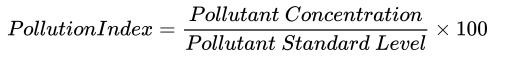

污染指数或污染标准指数（PSI）用于检查某个城市、地区或国家的污染水平。它考虑了六种空气污染物：二氧化硫（SO2）、颗粒物（PM10）、细颗粒物（PM2.5）、二氧化氮（NO2）、一氧化碳（CO）和臭氧（O3）。它在0–500之间缩放，可分为以下五个级别：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td>
<p><strong>PSI</strong></p>
</td>
<td>
<p><strong>Descriptor</strong></p>
</td>
<td>
<p><strong>General health effects</strong></p>
</td>
</tr>
<tr>
<td>
<p>0–50</p>
</td>
<td>
<p>Good</p>
</td>
<td>
<p>None.</p>
</td>
</tr>
<tr>
<td>
<p>51–100</p>
</td>
<td>
<p>Moderate</p>
</td>
<td>
<p>Few or none for the general population.</p>
</td>
</tr>
<tr>
<td>
<p>101–200</p>
</td>
<td>
<p>Unhealthy</p>
</td>
<td>
<p>Everyone may begin to experience health effects; members of sensitive groups may experience more serious health effects. Stay indoors.</p>
</td>
</tr>
<tr>
<td>
<p>201-300</p>
</td>
<td>
<p>Very unhealthy</p>
</td>
<td>
<p>Health warnings of emergency conditions. The entire population is more likely to be affected.</p>
</td>
</tr>
<tr>
<td>
<p>301+</p>
</td>
<td>
<p>Hazardous</p>
</td>
<td>
<p>Health alert: everyone may experience more serious health effects.</p>
</td>
</tr>
</tbody>
</table>

按小时计算，污染标准水平可视为80µg/m3。每日为50µg/m3。

根据随机值设计自己的GPU加速污染监测仪。在实验结束时，还要尝试使用真实世界的数据。

您可以通过以下链接获得解决方案方面的帮助：

# 小结

在本章中，我们用NumPy的比较例子来解释CuPy代码的一般语法。描述了在现有的水蟒环境中安装CuPy和Numba的步骤。设置CuPy和Numba的配置设置被一步一步地解释。我们还学习了计算机在丘比和努巴的工作原理。CuPy与NumPy和CUDA进行了比较，而Numba与NumPy、ROCm和CUDA进行了比较。对丘比和麻木也进行了复位研究。

在这个阶段，你现在应该能够测试你自己的CuPy和Numba程序。基于本书前面讨论的CUDA安装步骤，您还可以在现有CUDA环境中安装和配置CuPy。此外，您应该能够安装和配置Numba，基于我们的CUDA和ROCm安装过程。

现在，您应该考虑一下基于纯Python GPU编程的CuPy和Numba实现性能最大化的方法。这些选项将帮助您以更简单的方式解决计算问题。你现在可以开始尝试用你自己的公式来利用CuPy和Numba的GPU。强烈建议进行本章最后一节所述的关于污染指数的最后练习。您现在可以采用不同的方法来创建自己版本的污染控制监控器。

在下一章中，我们将继续探讨集装箱化领域。我们将了解不同的准备部署，可编程环境的GPU和他们的优势使用。除此之外，我们还将比较开放式、系统范围的环境和封闭式环境。